# Agents 

Chains는 고정된 처리 흐름을 구현하는 것이라면 Chains는 고정된 처리 흐름을 구현하는 것입니다.<br /><br />
예를 들어, 사용자가 입력한 내용을 바탕으로 필요에 따라 사내 문서를 Vector store에서 검색하여 답변하거나 웹상의 정보를 검색하여 답변해준다든지… 이런 작동을 할 수 있다면 LLM으로 실현할 수 있는 것이 크게 늘어날 것입니다.<br /> 
이러한 작동을 실현할 수 있는 것이 바로 랭체인의 ‘Agents’다.<br /> 
<br /> 
랭체인의 Agents를 사용하면 필요에 따라 다양한 도구를 사용하면서 LLM을 작동시킬 수 있다.<br />  
도구로는 Vector store를 통해 특정 분야의 데이터를 검색하여 사용하게 할 수도 있고, 구글과 같은 검색 엔진의 API를 사용하게 할 수도 있다.

### Agents 사용 예시
에이전트는 LLM이 스스로 판단하여 필요한 도구(Tool)를 선택하고 실행하는 구조를 말합니다.<br />
과거에는 프롬프트 엔지니어링 기법(ReAct 등)에 의존해 텍스트를 파싱하는 방식으로 에이전트를 구현했으나, 이는 파싱 에러에 취약했습니다.<br />
최신 에이전트는 LLM 제조사가 모델 자체에 내장한 Native Function Calling(네이티브 함수 호출) 기능을 활용합니다.<br />
개발자가 도구의 목록과 명세(Spec)를 API 파라미터로 전달하면, 모델이 알아서 구조화된 JSON 형태로 사용할 도구와 매개변수를 정확하게 지정해 줍니다.<br />
이를 통해 에이전트의 속도와 안정성이 비약적으로 향상되었습니다.<br />
랭체인(LangChain)에서는 이를 반영하여 Native Function Calling에 최적화된 에이전트 생성 함수(create_agent)를 제공합니다.

## 1. ReAct 방식

프롬프트 엔지니어링 기반의 에이전트 개념인 ReAct(Reasoning + Acting) 방식을 알아보겠습니다.<br />
<br />
ReAct는 LLM이 생각(Reasoning) 과 행동(Acting) 을 반복하면서 문제를 해결하는 대표적인 에이전트 기법입니다.<br />
과거의 LangChain에서는 Thought → Action → Observation → Final Answer 형식의 ReAct 프롬프트와 AgentExecutor를 이용하여 문자열을 파싱하고 Tool을 실행하는 방식으로 에이전트를 구현했습니다.<br />
<br />
그러나 LangChain 1.x에서는 내부 실행 엔진이 LangGraph 기반으로 재구성되면서 create_agent()를 사용하는 방식이 권장됩니다.<br /> 
또한 Gemini와 같은 최신 LLM은 Native Function Calling을 지원하므로, 개발자가 Thought, Action, Observation 형식의 프롬프트를 직접 작성하거나 문자열을 파싱할 필요가 없습니다.<br />
<br />
즉, ReAct의 핵심 개념(추론 → 행동 → 관찰 → 반복)은 그대로 유지되지만, 구현 방식은 텍스트 파싱 기반에서 Function Calling 기반으로 발전했습니다.

In [10]:
# 1. 라이브러리 설치
!pip install -U langchain
!pip install -U langchain-classic
!pip install -U langchain-google-genai

In [19]:
# 2. API KEY
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

In [20]:
# 3.Tool 만들기
import subprocess
from langchain_core.tools import tool

@tool
def terminal(command: str) -> str:
    """
    Linux 명령어를 실행합니다.
    """
    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )

    return result.stdout

In [21]:
# 4.LLM
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [22]:
# 5.ReAct Prompt 작성
from langchain_core.prompts import PromptTemplate

template = """
Answer the following questions as best you can.

You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer

Thought: you should always think about what to do

Action: the action to take, should be one of [{tool_names}]

Action Input: the input to the action

Observation: the result of the action

... (this Thought/Action/Action Input/Observation can repeat N times)

Thought: I now know the final answer

Final Answer: the final answer to the original input question


Example

Question: What files are in the sample_data directory?

Thought: I can use the terminal to list the files in the sample_data directory.

Action: terminal

Action Input: ls sample_data

Observation:
README.md
anscombe.json
mnist_train_small.csv

Thought: I now know the files in the sample_data directory.

Final Answer:
The sample_data directory contains README.md, anscombe.json and mnist_train_small.csv.


Begin!

Question: {input}

Thought:
{agent_scratchpad}
"""

prompt = PromptTemplate.from_template(template)

이 프롬프트의 첫머리에 적힌 영문은 ‘질문에 최대한 잘 답해 주세요.다음 도구를 사용할 수 있습니다.’라는 뜻이다.<br /> 
그리고 사용할 수 있는 도구를 나열할 곳에 {tools}라는 자리 표시자가 있다.<br />
그 아래에는 LLM의 출력이 따라야 할 형식이 지정돼 있는데, 다음 두 가지가 특히 중요하다.<br />
     ‘Action:’을 써서 액션을 지정한다.
     ‘Action Input:’을 써서 액션 입력을 지정한다.
이 프롬프트에 대해 LLM은 다음과 같은 응답을 반환한다.

입력 프롬프트가 ‘Thought:’로 끝났기 때문에 첫 번째 줄은 ‘sample_data 디렉터리의 파일 목록을 나열하기 위해 터미널을 사용할 수 있다’라는 LLM의 생각으로 되어 있습니다.<br /> 
그리고 Action으로 ‘terminal’이 지정돼 있고, Action Input으로 ‘ls sample_data’가 지정되어 있습니다.<br />
랭체인의 Agent는 이 응답 문자열에서 Action과 Action Input의 내용을 정규식으로 추출합니다.<br /> 
그리고 terminal이라는 도구에서 ‘ls sample_data’를 실행하고 싶다는 내용에 따라 실제로 셸에서 ‘ls sample_data’라는 명령을 실행한다.

In [24]:
# 6.Tool 목록
tools = [
    add,
    terminal
]

In [25]:
# 7.ReAct Agent 생성
from langchain_classic.agents import create_react_agent

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt
)

In [26]:
# 8.AgentExecutor 생성
from langchain_classic.agents import AgentExecutor

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)

In [ ]:
# 9.질문
response = agent_executor.invoke(
    {
        "input":"sample_data 디렉터리에 있는 파일 목록을 알려줘."
    }
)

In [ ]:
# 10. 결과 출력
print(response["output"])

In [ ]:
!pip install -U langchain
!pip install -U langchain-google-genai

### 2. Tools

랭체인의 Agents에는 다양한 툴을 부여할 수 있다. 예를 들어, 표 5.3과 같은 툴이 제공된다.<br />
표) Agent의 툴 예시<br />
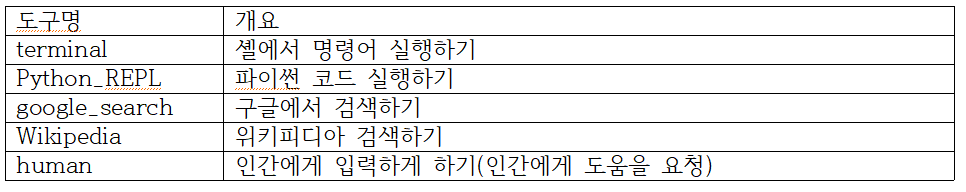<br />
툴의 실체는 매우 간단하며, 단순한 파이썬 함수다. 툴을 직접 만들 수 있습니다.

In [32]:
from langchain_core.tools import Tool
# 사용자가 정의한 커스텀 함수 및 도구(Tool) 설정
def my_super_func(param):
    return "42"

tools = [
    Tool.from_function(
        func=my_super_func,
        name="The_Answer",
        description="생명, 우주, 그리고 만물에 대한 궁극적인 질문에 대한 답을 구해야 할 때만 사용하세요."
    ),
]

In [ ]:
func : Tool이 호출될 때 실행할 Python 함수.
name : Agent가 Tool을 식별하기 위한 도구 이름
description : Tool의 사용 목적과 용도를 설명합니다. LLM이 어떤 Tool을 선택할지 판단하는 가장 중요한 정보
return_direct : True이면 Tool 실행 결과를 즉시 사용자에게 반환하고 Agent를 종료합니다. False이면 Tool 결과를 바탕으로 계속 추론
args_schema : Tool의 **입력값 형식(매개변수)**을 정의하는 Pydantic 모델입니다. 여러 개의 입력값이나 검증이 필요한 경우 사용
coroutine : 비동기(async) 함수를 Tool로 사용할 때 지정

In [ ]:
### Tool을 사용한 또다른 예
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent


# 1.Tool
@tool
def add(a: int, b: int) -> int:
    """
    두 숫자를 더합니다.
    """
    return a + b

# 2.LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


# 3.Agent
agent = create_agent(
    model=llm,
    tools=[add],
    system_prompt="당신은 친절한 AI 비서입니다."
)


# 4.질문
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "15와 27을 더해줘."
            }
        ]
    }
)

# 5.결과
print(response["messages"][-1].content)

## 3. Toolkits

동시에 사용할 수 있는 몇 가지 툴을 모아놓은 것이 Toolkits다. <<br />
예를 들어, Agents를 사용해 깃허브에 여러 가지 작업을 하고 싶다고 가정해 보자. <br />
이때 다음과 같이 여러 가지 도구를 준비하게 된다.<br />
	* Issue 목록 가져오기<br />
	* Issue 상세보기<br />
	* Issue에 댓글 달기<br />
	* 파일 만들기<br />
	* 파일 불러오기<br />
	* 파일 업데이트하기<br />
	* 파일 삭제하기<br />
랭체인에서 제공하는 Toolkits를 사용하면 이러한 툴을 한꺼번에 준비할 수 있다.<br />
앞서 언급한 깃허브의 조작이라면 GitHubToolkit을 통해 쉽게 툴을 구비할 수 있다.<br />
랭체인에는 이 외에도 다양한 Toolkits가 제공된다.<br />

In [ ]:
# 1. Tool 정의
from langchain_core.tools import tool

@tool
def list_issues() -> str:
    """Issue 목록을 조회합니다."""
    return "Issue #1, Issue #2, Issue #3"

@tool
def get_issue(issue_number: int) -> str:
    """Issue 상세 정보를 조회합니다."""
    return f"Issue {issue_number}의 상세 내용입니다."

@tool
def add_issue_comment(issue_number: int, comment: str) -> str:
    """Issue에 댓글을 등록합니다."""
    return f"Issue {issue_number}에 댓글이 등록되었습니다."

@tool
def create_file(filename: str, content: str) -> str:
    """파일을 생성합니다."""
    return f"{filename} 파일이 생성되었습니다."

@tool
def read_file(filename: str) -> str:
    """파일 내용을 읽습니다."""
    return f"{filename} 파일 내용입니다."

@tool
def update_file(filename: str, content: str) -> str:
    """파일 내용을 수정합니다."""
    return f"{filename} 파일이 수정되었습니다."

@tool
def delete_file(filename: str) -> str:
    """파일을 삭제합니다."""
    return f"{filename} 파일이 삭제되었습니다."

In [ ]:
# 2. Toolkit 생성
from langchain_core.tools import BaseToolkit
from typing import List


class GitHubToolkit(BaseToolkit):

    def get_tools(self) -> List:
        return [
            list_issues,
            get_issue,
            add_issue_comment,
            create_file,
            read_file,
            update_file,
            delete_file,
        ]

In [ ]:
# 3. Toolkit 사용
toolkit = GitHubToolkit()

tools = toolkit.get_tools()

In [ ]:
# 4. Tool 목록 확인
for tool in tools:
    print(tool.name)

In [ ]:
5. Agent에서 사용
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools
)

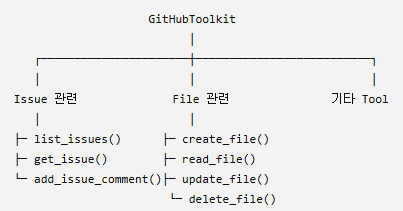

In [ ]:
# 파일 생성, 수정, 삭제가 가능한 프로그램
import os

# 1. Google API Key
os.environ["GOOGLE_API_KEY"] = "your_api_key"

# 2. Tool 정의
from langchain_core.tools import tool


@tool
def create_file(filename: str, content: str) -> str:
    """
    새로운 파일을 생성합니다.
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)

    return f"{filename} 파일이 생성되었습니다."


@tool
def read_file(filename: str) -> str:
    """
    파일 내용을 읽습니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    with open(filename, "r", encoding="utf-8") as f:
        return f.read()


@tool
def update_file(filename: str, content: str) -> str:
    """
    파일 내용을 수정합니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)

    return f"{filename} 파일이 수정되었습니다."


@tool
def delete_file(filename: str) -> str:
    """
    파일을 삭제합니다.
    """
    if not os.path.exists(filename):
        return "파일이 존재하지 않습니다."

    os.remove(filename)

    return f"{filename} 파일이 삭제되었습니다."


# 3. Toolkit 정의
from langchain_core.tools import BaseToolkit
from typing import List


class FileToolkit(BaseToolkit):

    def get_tools(self) -> List:
        return [
            create_file,
            read_file,
            update_file,
            delete_file
        ]


# 4. Toolkit 생성
toolkit = FileToolkit()

tools = toolkit.get_tools()


# 5. LLM 생성
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)


# 6. Agent 생성
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools
)


# 7. 실행
while True:

    question = input("\n질문 입력(종료: exit) : ")

    if question.lower() == "exit":
        break

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": question
                }
            ]
        }
    )

    print("\n==============================")
    print("AI 응답")
    print("==============================")

    print(response["messages"][-1].content)

In [ ]:
# 파일 생성 질문 예
memo.txt 파일을 만들고
안녕하세요 Toolkit입니다.
라고 저장해줘.

In [ ]:
# 파일 수정 질문 예
memo.txt 내용을
LangChain Toolkit 예제입니다.
로 수정해줘.

In [ ]:
# 파일 삭제 질문 예
memo.txt 파일을 삭제해줘.

## 4. Function calling을 사용하는 재미나이 Functions Agent

Function Calling은 LLM이 사용자의 요청을 해결하기 위해 필요한 외부 함수(도구)를 선택하고, 해당 함수의 이름과 입력값을 구조화된 형태(JSON 등)로 생성하여 실행 요청을 전달하는 메커니즘이다.<br />
<br /><br />
핵심 역할<br />
LLM = “무엇을 실행할지 결정”<br />
출력 = function name + arguments (구조화된 명령)<br />
실행 = 외부 시스템(개발자 코드 / API)<br />

예시 구조<br />
{<br />
  "name": "get_weather",<br />
  "arguments": {<br />
    "city": "Seoul"<br />
  }<br />
}<br />

In [ ]:
# 외부 코드 (실제 실행 부분) : 외부 시스템 (LLM 밖에서 실행되는 코드)
def get_weather(city):
    data = {
        "Seoul": "맑음 25도",
        "Busan": "흐림 22도",
        "Jeju": "비 20도"
    }
    return data.get(city, "정보 없음")

In [ ]:
# LLM이 준 결과
llm_output = '''
{
  "function": "get_weather",
  "arguments": {
    "city": "Seoul"
  }
}
'''

Function Calling의 목적
1. LLM의 한계를 보완 (실시간 데이터, DB 접근 불가)
2. 외부 시스템과 연결
3. 실행과 판단의 분리
3. AI 기능 확장

In [ ]:
import json

# 1. 실제 실행될 함수 (Tool 역할)
def get_weather(city: str):
    weather_db = {
        "Seoul": "맑음, 12도",
        "Busan": "흐림, 15도",
        "Tokyo": "비, 10도"
    }
    return weather_db.get(city, "정보 없음")


# 2. LLM이 생성했다고 가정한 Function Calling 결과
llm_response = {
    "name": "get_weather",
    "arguments": {
        "city": "Seoul"
    }
}

# 3. Function Calling 실행 처리기 (핵심 구조)
def run_function_call(call):
    func_name = call["name"]
    args = call["arguments"]

    if func_name == "get_weather":
        result = get_weather(**args)
        return result

    return "Unknown function"


# 4. 실행
result = run_function_call(llm_response)

print("함수 실행 결과:", result)

## LangGraph
생성형 AI가 발전하면서 단순히 질문에 답변하는 수준을 넘어, 여러 작업을 스스로 판단하여 수행하는 AI Agent에 대한 관심이 커지고 있다.<br />
예를 들어 사용자가 "GitHub에서 이슈를 조회하고, 필요한 파일을 생성한 후 결과를 요약해 줘."라고 요청하면 AI는 단순히 텍스트를 생성하는 것이 아니라 여러 단계를 거쳐 작업을 수행해야 힙니다.

In [ ]:
1. Node
Node는 하나의 작업을 의미한다.
사용자 입력
LLM 호출
Tool 실행
데이터 저장
최종 응답

모두 하나의 Node가 될 수 있다
Tool도 하나의 Node
함도 하나의 Node

In [ ]:
2. Edge
Edge는 Node와 Node를 연결하는 선이다.
사용자 입력 -> LLM 호출 -> Tool 실행 -> 최종 응답
여기서 화살표가 바로 Edge이다

LangGraph에서는 이러한 Node와 Edge를 직접 설계하여 자신만의 AI Workflow를 만든다.

In [ ]:
3. State
State는 그래프 전체를 이동하면서 공유되는 데이터이다.

In [ ]:
{
    "question": "서울 날씨 알려줘",
    "tool_result": "",
    "answer": ""
}
# 처음에는 질문만 들어 있다.

In [ ]:
# LLM Node를 지나면
{
    "question": "서울 날씨 알려줘",
    "tool": "get_weather",
    "city": "서울"
}
# 으로 변경될 수 있다.

In [ ]:
#Tool Node를 지나면
{
    "question": "서울 날씨 알려줘",
    "tool": "get_weather",
    "city": "서울",
    "tool_result": "맑음"
}
# 이 된다.

In [ ]:
# 마지막으로 LLM Node를 다시 거치면
{
    "question": "서울 날씨 알려줘",
    "tool_result": "맑음",
    "answer": "서울은 현재 맑습니다."
}
#이 된다.   

In [21]:
from typing import TypedDict
import requests

from langgraph.graph import StateGraph, START, END

# State
class WeatherState(TypedDict):
    seoul: str
    busan: str


# 외부 API 호출 함수
def get_weather(latitude, longitude):
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={latitude}"
        f"&longitude={longitude}"
        "&current=temperature_2m,weather_code"
    )
    response = requests.get(url)
    data = response.json()
    current = data["current"]
    return f"{current['temperature_2m']}°C"



# Node
def seoul_node(state):

    print("서울 날씨 조회 중...")

    state["seoul"] = get_weather(
        37.5665,
        126.9780
    )

    return state


def busan_node(state):

    print("부산 날씨 조회 중...")

    state["busan"] = get_weather(
        35.1796,
        129.0756
    )

    return state


def print_node(state):

    print("\n===== 현재 날씨 =====")

    print(f"서울 : {state['seoul']}")

    print(f"부산 : {state['busan']}")

    return state


# Graph
builder = StateGraph(WeatherState)

builder.add_node("seoul", seoul_node)
builder.add_node("busan", busan_node)
builder.add_node("print", print_node)

builder.add_edge(START, "seoul")
builder.add_edge("seoul", "busan")
builder.add_edge("busan", "print")
builder.add_edge("print", END)

graph = builder.compile()

graph.invoke({})

서울 날씨 조회 중...
부산 날씨 조회 중...

===== 현재 날씨 =====
서울 : 29.2°C
부산 : 26.4°C


{'seoul': '29.2°C', 'busan': '26.4°C'}